
# Notebook 4 — Faithfulness Intervention for BioGPT Attention-Graph Explanations

This notebook adds the **faithfulness evidence** requested after review of the manuscript.

It tests whether tokens ranked highly by:

- proposed \(\Omega_{MH}\),
- Dangling Centrality \(\phi_C\),
- raw aggregated attention,
- random selection,

actually have a larger effect on BioGPT's multiple-choice output when removed from the **clinical question stem only**.

For each question and each removal level \(k\in\{5\%,10\%,20\%\}\), the notebook reports:

\[
\Delta P_k
=
P_{\mathrm{original}}(y^*)
-
P_{\mathrm{perturbed},k}(y^*)
\]

where \(y^*\) is the model's original predicted option, and

\[
\mathrm{Flip}_k
=
\mathbf{1}
[
\hat y_{\mathrm{perturbed},k}\neq \hat y_{\mathrm{original}}
].
\]

It also computes **AOPC**, paired **Wilcoxon signed-rank tests**, publication-ready tables, figures, CSV files, and a ZIP archive.

> **Important:** first run the pilot on one question. Only after the pilot is correct should you set `RUN_FULL_200 = True`.


## 1. Install required packages

In [1]:

!pip -q install "transformers>=4.57,<5" "datasets>=4.0,<5" accelerate sentencepiece sacremoses networkx scipy openpyxl


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867.8/867.8 kB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 112.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
gradio 6.27.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.


## 2. Imports and reproducibility

In [2]:

import gc
import json
import math
import random
import shutil
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from scipy.stats import wilcoxon
from transformers import AutoModelForCausalLM, AutoTokenizer

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Device:", DEVICE)


PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
Device: cuda


## 3. Configuration

In [3]:

MODEL_NAME = "microsoft/biogpt"

# Dataset used in the manuscript.
DATASET_NAME = "openlifescienceai/medmcqa"
DATASET_SPLIT = "validation"

# Manuscript experiment size.
N_QUESTIONS = 200

# First validate one case. Change to True only after the pilot works.
RUN_FULL_200 = False
PILOT_INDEX = 0

MAX_LENGTH = 256

# Must match the graph construction used in the earlier notebooks/manuscript.
TOP_K_EDGES_PER_NODE = 5

# Intervention settings.
REMOVAL_FRACTIONS = [0.05, 0.10, 0.20]
RANDOM_REPEATS = 10

# Refined entropy uses normalized directed total degree d_i / [2(n-1)].
# If your earlier Omega_MH notebook used a different normalization,
# replace only this helper later; do not mix definitions across experiments.
EPS = 1e-12

# The manuscript reports 40.5% on the earlier 200-question experiment.
# This notebook prints its own baseline. If it differs materially, do not
# silently combine the two result sets; use the exact earlier option-scoring
# function or update the manuscript consistently.
REPORTED_BASELINE_ACCURACY = 0.405
BASELINE_TOLERANCE = 0.03

OUTPUT_DIR = Path("/content/faithfulness_biogpt_medmcqa")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)


Output directory: /content/faithfulness_biogpt_medmcqa


## 4. Load BioGPT

In [4]:

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager",
    torch_dtype=torch.float32,
    low_cpu_mem_usage=True,
)
model.config.output_attentions = True
model.config.use_cache = False
model.config.return_dict = True
model.to(DEVICE)
model.eval()

print("Model:", model.__class__.__name__)
print("Layers:", model.config.num_hidden_layers)
print("Heads:", model.config.num_attention_heads)
print("Hidden size:", model.config.hidden_size)


config.json:   0%|          | 0.00/595 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

Model: BioGptForCausalLM
Layers: 24
Heads: 16
Hidden size: 1024


model.safetensors:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

## 5. Load and normalize MedMCQA

In [5]:

dataset = load_dataset(
    DATASET_NAME,
    split=DATASET_SPLIT,
    trust_remote_code=True
)

print("Samples:", len(dataset))
print("Columns:", dataset.column_names)
print(dataset[0])


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'openlifescienceai/medmcqa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'openlifescienceai/medmcqa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/85.9M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/936k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.48M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/182822 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6150 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4183 [00:00<?, ? examples/s]

Samples: 4183
Columns: ['id', 'question', 'opa', 'opb', 'opc', 'opd', 'cop', 'choice_type', 'exp', 'subject_name', 'topic_name']
{'id': '45258d3d-b974-44dd-a161-c3fccbdadd88', 'question': 'Which of the following is not true for myelinated nerve fibers:', 'opa': 'Impulse through myelinated fibers is slower than non-myelinated fibers', 'opb': 'Membrane currents are generated at nodes of Ranvier', 'opc': 'Saltatory conduction of impulses is seen', 'opd': 'Local anesthesia is effective only when the nerve is not covered by myelin sheath', 'cop': 0, 'choice_type': 'multi', 'exp': None, 'subject_name': 'Physiology', 'topic_name': None}


In [6]:

def normalize_sample(sample):
    """Return question, ordered option dict, and zero-based correct index.

    Handles common MedMCQA schemas and the options-dictionary schema used
    in earlier notebooks.
    """
    question = str(sample["question"]).strip()

    # Common native MedMCQA schema: opa, opb, opc, opd, cop.
    if all(key in sample for key in ["opa", "opb", "opc", "opd"]):
        options = {
            "A": str(sample["opa"]).strip(),
            "B": str(sample["opb"]).strip(),
            "C": str(sample["opc"]).strip(),
            "D": str(sample["opd"]).strip(),
        }
        correct_idx = int(sample["cop"]) if sample.get("cop") is not None else None
        return question, options, correct_idx

    # Generic options schema.
    options_raw = sample.get("options")
    options = {}

    if isinstance(options_raw, dict):
        if "key" in options_raw and "value" in options_raw:
            options = {
                str(k): str(v).strip()
                for k, v in zip(options_raw["key"], options_raw["value"])
            }
        else:
            options = {str(k): str(v).strip() for k, v in options_raw.items()}

    elif isinstance(options_raw, list):
        for i, item in enumerate(options_raw):
            key = chr(65 + i)
            if isinstance(item, dict):
                options[str(item.get("key", key))] = str(
                    item.get("value", item.get("text", ""))
                ).strip()
            else:
                options[key] = str(item).strip()

    if not options:
        raise ValueError("Could not recover answer options from this sample.")

    answer_idx = sample.get("answer_idx", sample.get("answer"))
    correct_idx = None

    if answer_idx is not None:
        if isinstance(answer_idx, str):
            stripped = answer_idx.strip()
            if stripped in options:
                correct_idx = list(options.keys()).index(stripped)
            else:
                try:
                    correct_idx = int(stripped)
                except Exception:
                    correct_idx = None
        else:
            correct_idx = int(answer_idx)

    return question, options, correct_idx


q0, opts0, y0 = normalize_sample(dataset[0])
print(q0)
print(opts0)
print("Correct index:", y0)


Which of the following is not true for myelinated nerve fibers:
{'A': 'Impulse through myelinated fibers is slower than non-myelinated fibers', 'B': 'Membrane currents are generated at nodes of Ranvier', 'C': 'Saltatory conduction of impulses is seen', 'D': 'Local anesthesia is effective only when the nerve is not covered by myelin sheath'}
Correct index: 0


## 6. Prompt and multiple-choice probability scoring

In [7]:

def build_prompt(question, options):
    lines = [
        "Clinical question:",
        str(question).strip(),
        "",
        "Possible answers:",
    ]
    lines.extend(f"{k}. {v}" for k, v in options.items())
    lines.extend(["", "Answer:"])
    return "\n".join(lines)


def continuation_logprob(prompt_ids_1d, continuation_text):
    """Length-normalized causal log-probability of one candidate continuation."""
    continuation_ids = tokenizer(
        " " + str(continuation_text).strip(),
        add_special_tokens=False,
        return_tensors="pt"
    )["input_ids"][0]

    full_ids = torch.cat([
        prompt_ids_1d.detach().cpu(),
        continuation_ids.detach().cpu()
    ])

    labels = full_ids.clone()
    prompt_len = len(prompt_ids_1d)
    labels[:prompt_len] = -100

    input_ids = full_ids.unsqueeze(0).to(DEVICE)
    labels = labels.unsqueeze(0).to(DEVICE)

    with torch.inference_mode():
        out = model(
            input_ids=input_ids,
            labels=labels,
            use_cache=False,
            return_dict=True
        )

    # Hugging Face causal-LM loss is mean negative log-likelihood
    # over the unmasked continuation tokens.
    return -float(out.loss.detach().cpu())


def score_options(prompt_ids_1d, options):
    keys = list(options.keys())
    values = [options[k] for k in keys]

    scores = np.array(
        [continuation_logprob(prompt_ids_1d, text) for text in values],
        dtype=float
    )

    # Convert normalized log scores to a 4-way probability distribution.
    shifted = scores - scores.max()
    probs = np.exp(shifted)
    probs = probs / probs.sum()

    pred_idx = int(np.argmax(probs))

    return {
        "keys": keys,
        "scores": scores,
        "probs": probs,
        "pred_idx": pred_idx,
        "pred_key": keys[pred_idx],
        "pred_prob": float(probs[pred_idx]),
    }


## 7. Attention extraction and subword-to-token aggregation

In [8]:

SPECIAL_TOKENS = set(tokenizer.all_special_tokens)

def merge_biogpt_subwords(tokens):
    merged_tokens = []
    groups = []
    current_pieces = []
    current_indices = []

    def close_current():
        nonlocal current_pieces, current_indices
        if current_indices:
            text = "".join(current_pieces).strip()
            if not text:
                text = "".join(str(tokens[i]) for i in current_indices)
            merged_tokens.append(text)
            groups.append(current_indices.copy())
        current_pieces = []
        current_indices = []

    for index, raw_token in enumerate(tokens):
        token = str(raw_token)

        if token in SPECIAL_TOKENS:
            close_current()
            merged_tokens.append(token)
            groups.append([index])

        elif token.endswith("</w>"):
            current_pieces.append(token[:-4])
            current_indices.append(index)
            close_current()

        elif token.startswith("Ġ") or token.startswith("▁"):
            close_current()
            current_pieces = [token[1:]]
            current_indices = [index]

        elif token.startswith("##"):
            current_pieces.append(token[2:])
            current_indices.append(index)

        else:
            current_pieces.append(token)
            current_indices.append(index)

    close_current()

    flattened = [i for group in groups for i in group]
    if sorted(flattened) != list(range(len(tokens))):
        raise RuntimeError("Subword merging lost or duplicated indices.")

    return merged_tokens, groups


def aggregate_attention_to_words(subword_attention, groups):
    n = len(groups)
    word_attention = np.zeros((n, n), dtype=np.float64)

    for source_word, source_indices in enumerate(groups):
        for target_word, target_indices in enumerate(groups):
            block = subword_attention[np.ix_(source_indices, target_indices)]
            word_attention[source_word, target_word] = float(block.mean())

    return word_attention


def extract_prompt_attention(prompt):
    encoded = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
        add_special_tokens=True,
    )

    input_ids_cpu = encoded["input_ids"][0].clone()
    model_inputs = {
        key: value.to(DEVICE)
        for key, value in encoded.items()
    }

    with torch.inference_mode():
        outputs = model(
            **model_inputs,
            output_attentions=True,
            use_cache=False,
            return_dict=True,
        )

    if outputs.attentions is None:
        raise RuntimeError("BioGPT returned no attention tensors.")

    # Same aggregation used in the earlier attention-graph notebook:
    # mean over heads inside each layer, then mean over layers.
    layer_means = [
        layer_attention[0].float().mean(dim=0).cpu()
        for layer_attention in outputs.attentions
    ]

    mean_subword_attention = (
        torch.stack(layer_means, dim=0)
        .mean(dim=0)
        .numpy()
        .astype(np.float64)
    )

    subword_tokens = tokenizer.convert_ids_to_tokens(input_ids_cpu.tolist())
    merged_tokens, groups = merge_biogpt_subwords(subword_tokens)
    merged_attention = aggregate_attention_to_words(
        mean_subword_attention,
        groups
    )

    return {
        "prompt_ids": input_ids_cpu,
        "subword_tokens": subword_tokens,
        "merged_tokens": merged_tokens,
        "groups": groups,
        "subword_attention": mean_subword_attention,
        "merged_attention": merged_attention,
    }


## 8. Locate question-stem tokens only

In [9]:

def find_subsequence(sequence, subsequence):
    if len(subsequence) == 0 or len(subsequence) > len(sequence):
        return None

    for start in range(len(sequence) - len(subsequence) + 1):
        if sequence[start:start + len(subsequence)] == subsequence:
            return start, start + len(subsequence)

    return None


def question_subword_span(prompt_ids, question):
    """Find question-token span inside the full prompt.

    Exact token-id subsequence matching is attempted first.
    A prefix-length fallback is used only if needed.
    """
    prompt_list = prompt_ids.tolist()

    question_ids = tokenizer(
        str(question).strip(),
        add_special_tokens=False
    )["input_ids"]

    exact = find_subsequence(prompt_list, question_ids)
    if exact is not None:
        return exact

    prefix = "Clinical question:\n"
    prefix_ids = tokenizer(
        prefix,
        add_special_tokens=False
    )["input_ids"]

    prefix_plus_question_ids = tokenizer(
        prefix + str(question).strip(),
        add_special_tokens=False
    )["input_ids"]

    start = len(prefix_ids)
    end = len(prefix_plus_question_ids)

    # Account for a leading special token if present in full prompt encoding.
    offset = max(0, len(prompt_list) - len(
        tokenizer(build_prompt(question, {"A":"x"}), add_special_tokens=False)["input_ids"]
    ))
    start += offset
    end += offset

    return start, min(end, len(prompt_list))


def eligible_question_nodes(groups, q_start, q_end, merged_tokens):
    eligible = []

    for word_index, indices in enumerate(groups):
        if (
            indices
            and min(indices) >= q_start
            and max(indices) < q_end
            and merged_tokens[word_index] not in SPECIAL_TOKENS
            and any(ch.isalnum() for ch in str(merged_tokens[word_index]))
        ):
            eligible.append(word_index)

    return eligible


## 9. Sparse directed graph, published Dangling Centrality, entropy and \(\Omega_{MH}\)

In [10]:

def build_sparse_attention_graph(tokens, attention_matrix, top_k=5):
    graph = nx.DiGraph()

    retained = []
    for node_id, token in enumerate(tokens):
        text = str(token).strip()

        if token in SPECIAL_TOKENS:
            continue
        if not text or not any(ch.isalnum() for ch in text):
            continue

        retained.append(node_id)
        graph.add_node(
            int(node_id),
            token=str(token),
            position=int(node_id)
        )

    for source_id in retained:
        candidates = []

        for target_id in retained:
            if source_id == target_id:
                continue

            weight = float(attention_matrix[source_id, target_id])

            if np.isfinite(weight) and weight > 0:
                candidates.append((target_id, weight))

        candidates.sort(key=lambda item: (-item[1], item[0]))

        for target_id, weight in candidates[:top_k]:
            graph.add_edge(
                int(source_id),
                int(target_id),
                weight=weight,
                attention=weight
            )

    return graph


def communication_score(undirected_graph):
    """Published reciprocal shortest-path communication sum over unordered pairs."""
    score = 0.0

    for source, lengths in nx.all_pairs_shortest_path_length(undirected_graph):
        for target, distance in lengths.items():
            if source < target and distance > 0:
                score += 1.0 / float(distance)

    return score


def dangling_centrality(graph):
    """Published unweighted undirected structural-projection DC."""
    U = nx.Graph()
    U.add_nodes_from(graph.nodes())
    U.add_edges_from((u, v) for u, v in graph.edges() if u != v)

    base = communication_score(U)

    dc = {}
    if base <= 0:
        return {node: 0.0 for node in U.nodes()}

    for node in U.nodes():
        perturbed = U.copy()

        incident = list(perturbed.edges(node))
        perturbed.remove_edges_from(incident)

        after = communication_score(perturbed)
        dc[node] = (base - after) / base

    return dc


def attention_entropy_and_omega(graph, dc):
    n = max(graph.number_of_nodes(), 1)

    rows = []

    for node in graph.nodes():
        outgoing = [
            float(data["weight"])
            for _, _, data in graph.out_edges(node, data=True)
            if float(data["weight"]) > 0
        ]

        k_i = len(outgoing)

        if k_i <= 1:
            H_i = 0.0
        else:
            weights = np.asarray(outgoing, dtype=float)
            p = weights / weights.sum()
            H_i = -float(np.sum(p * np.log(p + EPS))) / math.log(k_i)

        total_degree = graph.in_degree(node) + graph.out_degree(node)

        if n <= 1:
            degree_norm = 0.0
        else:
            degree_norm = total_degree / (2.0 * (n - 1))
            degree_norm = float(np.clip(degree_norm, 0.0, 1.0))

        H_star = H_i * (1.0 - degree_norm)
        omega = float(dc.get(node, 0.0)) * H_star

        rows.append({
            "node_id": int(node),
            "token": graph.nodes[node].get("token", str(node)),
            "phi_C": float(dc.get(node, 0.0)),
            "H": H_i,
            "degree_norm": degree_norm,
            "H_star": H_star,
            "Omega_MH": omega,
        })

    return pd.DataFrame(rows)


## 10. Raw-attention baseline and token rankings

In [11]:

def create_rank_table(attention_bundle):
    merged_attention = attention_bundle["merged_attention"]
    merged_tokens = attention_bundle["merged_tokens"]
    groups = attention_bundle["groups"]
    prompt_ids = attention_bundle["prompt_ids"]

    graph = build_sparse_attention_graph(
        merged_tokens,
        merged_attention,
        top_k=TOP_K_EDGES_PER_NODE
    )

    dc = dangling_centrality(graph)
    scores = attention_entropy_and_omega(graph, dc)

    # Raw-attention baseline = total aggregated attention received by the token.
    raw_received = merged_attention.copy()
    np.fill_diagonal(raw_received, 0.0)
    raw_received = raw_received.sum(axis=0)

    scores["Raw_Attention"] = scores["node_id"].map(
        lambda node: float(raw_received[int(node)])
    )

    return graph, scores


## 11. Erasure intervention helpers

In [12]:

def remove_word_groups_from_prompt(prompt_ids, groups, selected_word_indices):
    remove_subword_indices = set()

    for word_index in selected_word_indices:
        remove_subword_indices.update(groups[int(word_index)])

    kept = [
        token_id
        for idx, token_id in enumerate(prompt_ids.tolist())
        if idx not in remove_subword_indices
    ]

    if len(kept) == 0:
        raise RuntimeError("Intervention removed the entire prompt.")

    return torch.tensor(kept, dtype=torch.long)


def top_fraction_nodes(score_table, eligible_nodes, column, fraction):
    subset = score_table[
        score_table["node_id"].isin(eligible_nodes)
    ].copy()

    if subset.empty:
        return []

    subset = subset.sort_values(
        [column, "node_id"],
        ascending=[False, True]
    )

    number = max(1, int(math.ceil(fraction * len(subset))))
    number = min(number, len(subset))

    return subset.head(number)["node_id"].astype(int).tolist()


def random_fraction_nodes(eligible_nodes, fraction, rng):
    if not eligible_nodes:
        return []

    number = max(1, int(math.ceil(fraction * len(eligible_nodes))))
    number = min(number, len(eligible_nodes))

    return sorted(
        rng.choice(
            np.asarray(eligible_nodes, dtype=int),
            size=number,
            replace=False
        ).astype(int).tolist()
    )


def run_intervention(
    prompt_ids,
    groups,
    options,
    original_prediction,
    selected_nodes
):
    perturbed_ids = remove_word_groups_from_prompt(
        prompt_ids,
        groups,
        selected_nodes
    )

    perturbed = score_options(perturbed_ids, options)

    original_idx = original_prediction["pred_idx"]
    original_prob_of_original_choice = float(
        original_prediction["probs"][original_idx]
    )
    perturbed_prob_of_original_choice = float(
        perturbed["probs"][original_idx]
    )

    delta_p = (
        original_prob_of_original_choice
        - perturbed_prob_of_original_choice
    )

    flip = int(perturbed["pred_idx"] != original_idx)

    return {
        "delta_p": float(delta_p),
        "flip": flip,
        "perturbed_pred_idx": int(perturbed["pred_idx"]),
        "perturbed_pred_key": perturbed["pred_key"],
        "perturbed_original_choice_prob": perturbed_prob_of_original_choice,
        "perturbed_probs": perturbed["probs"].tolist(),
    }


## 12. Run one question end-to-end

In [13]:

def analyze_one_question(question_index, random_repeats=RANDOM_REPEATS):
    sample = dataset[int(question_index)]
    question, options, correct_idx = normalize_sample(sample)
    prompt = build_prompt(question, options)

    bundle = extract_prompt_attention(prompt)
    graph, score_table = create_rank_table(bundle)

    q_start, q_end = question_subword_span(
        bundle["prompt_ids"],
        question
    )

    eligible_nodes = eligible_question_nodes(
        bundle["groups"],
        q_start,
        q_end,
        bundle["merged_tokens"]
    )

    # Keep only nodes retained in the sparse graph.
    graph_nodes = set(graph.nodes())
    eligible_nodes = [
        node for node in eligible_nodes
        if node in graph_nodes
    ]

    if len(eligible_nodes) < 3:
        raise RuntimeError(
            f"Only {len(eligible_nodes)} eligible question nodes found."
        )

    original = score_options(
        bundle["prompt_ids"],
        options
    )

    rows = []

    deterministic_methods = {
        "Omega_MH": "Omega_MH",
        "phi_C": "phi_C",
        "Raw_Attention": "Raw_Attention",
    }

    for fraction in REMOVAL_FRACTIONS:
        for method_name, score_column in deterministic_methods.items():
            chosen = top_fraction_nodes(
                score_table,
                eligible_nodes,
                score_column,
                fraction
            )

            result = run_intervention(
                bundle["prompt_ids"],
                bundle["groups"],
                options,
                original,
                chosen
            )

            rows.append({
                "question_index": int(question_index),
                "method": method_name,
                "fraction": float(fraction),
                "repeat": 0,
                "n_eligible_nodes": len(eligible_nodes),
                "n_removed_nodes": len(chosen),
                "removed_nodes": json.dumps(chosen),
                "removed_tokens": json.dumps([
                    bundle["merged_tokens"][node]
                    for node in chosen
                ], ensure_ascii=False),
                "original_pred_idx": int(original["pred_idx"]),
                "original_pred_key": original["pred_key"],
                "original_pred_prob": float(original["pred_prob"]),
                "correct_idx": (
                    int(correct_idx)
                    if correct_idx is not None
                    else np.nan
                ),
                "original_correct": (
                    int(original["pred_idx"] == correct_idx)
                    if correct_idx is not None
                    else np.nan
                ),
                **result
            })

        rng = np.random.default_rng(SEED + int(question_index) * 1000 + int(fraction * 100))

        for repeat in range(random_repeats):
            chosen = random_fraction_nodes(
                eligible_nodes,
                fraction,
                rng
            )

            result = run_intervention(
                bundle["prompt_ids"],
                bundle["groups"],
                options,
                original,
                chosen
            )

            rows.append({
                "question_index": int(question_index),
                "method": "Random",
                "fraction": float(fraction),
                "repeat": int(repeat),
                "n_eligible_nodes": len(eligible_nodes),
                "n_removed_nodes": len(chosen),
                "removed_nodes": json.dumps(chosen),
                "removed_tokens": json.dumps([
                    bundle["merged_tokens"][node]
                    for node in chosen
                ], ensure_ascii=False),
                "original_pred_idx": int(original["pred_idx"]),
                "original_pred_key": original["pred_key"],
                "original_pred_prob": float(original["pred_prob"]),
                "correct_idx": (
                    int(correct_idx)
                    if correct_idx is not None
                    else np.nan
                ),
                "original_correct": (
                    int(original["pred_idx"] == correct_idx)
                    if correct_idx is not None
                    else np.nan
                ),
                **result
            })

    return {
        "question": question,
        "options": options,
        "correct_idx": correct_idx,
        "prompt": prompt,
        "bundle": bundle,
        "graph": graph,
        "score_table": score_table,
        "eligible_nodes": eligible_nodes,
        "original_prediction": original,
        "interventions": pd.DataFrame(rows),
    }


## 13. Pilot: inspect rankings and faithfulness on one question

In [14]:

pilot = analyze_one_question(
    PILOT_INDEX,
    random_repeats=RANDOM_REPEATS
)

print("Question:")
print(pilot["question"])
print("\nOptions:", pilot["options"])
print("Correct index:", pilot["correct_idx"])

print("\nOriginal prediction:")
print(pilot["original_prediction"])

eligible_rankings = pilot["score_table"][
    pilot["score_table"]["node_id"].isin(pilot["eligible_nodes"])
].copy()

print("\nTop question-stem tokens by Omega_MH:")
display(
    eligible_rankings
    .sort_values("Omega_MH", ascending=False)
    [["node_id", "token", "phi_C", "H_star", "Omega_MH", "Raw_Attention"]]
    .head(15)
)

print("\nPilot intervention results:")
display(
    pilot["interventions"][
        ["method", "fraction", "repeat", "n_removed_nodes",
         "removed_tokens", "delta_p", "flip",
         "perturbed_pred_key"]
    ]
)


Question:
Which of the following is not true for myelinated nerve fibers:

Options: {'A': 'Impulse through myelinated fibers is slower than non-myelinated fibers', 'B': 'Membrane currents are generated at nodes of Ranvier', 'C': 'Saltatory conduction of impulses is seen', 'D': 'Local anesthesia is effective only when the nerve is not covered by myelin sheath'}
Correct index: 0

Original prediction:
{'keys': ['A', 'B', 'C', 'D'], 'scores': array([-0.60458535, -0.84483397, -1.15907693, -0.71804368]), 'probs': array([0.30735772, 0.24171604, 0.17653527, 0.27439096]), 'pred_idx': 0, 'pred_key': 'A', 'pred_prob': 0.3073577218215203}

Top question-stem tokens by Omega_MH:


,node_id,token,phi_C,H_star,Omega_MH,Raw_Attention
2,4,Which,0.045077,0.770849,0.034748,1.192700
10,12,myelinated,0.038389,0.828019,0.031787,0.864561
12,14,fibers,0.035955,0.872375,0.031366,0.644353
8,10,true,0.030914,0.915647,0.028306,0.457186
9,11,for,0.031776,0.884631,0.028110,0.776687
5,7,following,0.031129,0.860390,0.026783,0.633855
3,5,of,0.035330,0.745098,0.026325,0.995085
7,9,not,0.028157,0.919437,0.025888,0.467542
6,8,is,0.028157,0.918072,0.025850,0.572432
11,13,nerve,0.034059,0.747611,0.025463,0.614807



Pilot intervention results:


,method,fraction,repeat,n_removed_nodes,removed_tokens,delta_p,flip,perturbed_pred_key
0,Omega_MH,0.05,0,1,"[""Which""]",-0.005251,0,A
1,phi_C,0.05,0,1,"[""Which""]",-0.005251,0,A
2,Raw_Attention,0.05,0,1,"[""Which""]",-0.005251,0,A
3,Random,0.05,0,1,"[""of""]",-0.000244,0,A
4,Random,0.05,1,1,"[""myelinated""]",-0.009343,0,A
5,Random,0.05,2,1,"[""not""]",-0.004017,0,A
6,Random,0.05,3,1,"[""myelinated""]",-0.009343,0,A
7,Random,0.05,4,1,"[""is""]",-0.000810,0,A
8,Random,0.05,5,1,"[""not""]",-0.004017,0,A
9,Random,0.05,6,1,"[""of""]",-0.000244,0,A



### Pilot validation checklist

Before running all 200 questions, confirm:

1. The displayed top-ranked tokens are from the **question stem**, not from answer options.
2. The original prediction and option probabilities are sensible.
3. Removing a token does not remove any option text.
4. `delta_p > 0` means removal reduced the model's probability for its original predicted answer.
5. Random removal runs successfully for all three perturbation levels.

If the original multiple-choice scoring does **not** match the earlier study's inference rule, replace `score_options()` with the exact earlier function before using the final faithfulness numbers in the manuscript.


## 14. Full 200-question experiment

In [15]:

all_rows = []
failed_questions = []

if not RUN_FULL_200:
    print(
        "Full run is OFF. After checking the pilot, set "
        "RUN_FULL_200 = True in Section 3 and rerun from the top."
    )
else:
    start_time = time.time()
    n_to_run = min(N_QUESTIONS, len(dataset))

    for question_index in range(n_to_run):
        try:
            result = analyze_one_question(
                question_index,
                random_repeats=RANDOM_REPEATS
            )

            all_rows.append(result["interventions"])

        except Exception as error:
            failed_questions.append({
                "question_index": question_index,
                "error": repr(error)
            })

        if (question_index + 1) % 10 == 0:
            elapsed = (time.time() - start_time) / 60
            print(
                f"Processed {question_index + 1}/{n_to_run} "
                f"| elapsed {elapsed:.1f} min "
                f"| failures {len(failed_questions)}"
            )

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if all_rows:
        faithfulness_df = pd.concat(
            all_rows,
            ignore_index=True
        )
    else:
        faithfulness_df = pd.DataFrame()

    failure_df = pd.DataFrame(failed_questions)

    print("Completed rows:", len(faithfulness_df))
    print("Failed questions:", len(failure_df))

    display(failure_df.head())


Full run is OFF. After checking the pilot, set RUN_FULL_200 = True in Section 3 and rerun from the top.


## 15. Baseline consistency check

In [16]:

if RUN_FULL_200 and not faithfulness_df.empty:
    baseline = (
        faithfulness_df
        .drop_duplicates("question_index")
        [["question_index", "original_pred_idx",
          "correct_idx", "original_correct",
          "original_pred_prob"]]
        .copy()
    )

    valid = baseline["original_correct"].notna()

    if valid.any():
        accuracy = float(
            baseline.loc[valid, "original_correct"].mean()
        )
        mean_prob = float(
            baseline.loc[valid, "original_pred_prob"].mean()
        )

        print("Notebook-4 baseline accuracy:", accuracy)
        print("Notebook-4 mean predicted-option probability:", mean_prob)
        print("Previously reported manuscript accuracy:", REPORTED_BASELINE_ACCURACY)

        difference = abs(
            accuracy - REPORTED_BASELINE_ACCURACY
        )

        if difference > BASELINE_TOLERANCE:
            print(
                "\nWARNING: baseline differs materially from the manuscript. "
                "Do not combine these faithfulness results with the old baseline "
                "until the exact earlier option-scoring function is restored, "
                "or update the manuscript consistently."
            )
        else:
            print("\nBaseline is within the configured tolerance.")


## 16. Aggregate random repetitions and summarize faithfulness

In [17]:

def aggregate_random_repeats(df):
    random_df = df[df["method"] == "Random"].copy()

    random_agg = (
        random_df
        .groupby(["question_index", "fraction"], as_index=False)
        .agg(
            delta_p=("delta_p", "mean"),
            flip=("flip", "mean"),
            original_pred_prob=("original_pred_prob", "first"),
            original_correct=("original_correct", "first"),
        )
    )
    random_agg["method"] = "Random"

    nonrandom = df[df["method"] != "Random"].copy()

    nonrandom_agg = nonrandom[
        ["question_index", "method", "fraction",
         "delta_p", "flip", "original_pred_prob",
         "original_correct"]
    ].copy()

    return pd.concat(
        [nonrandom_agg, random_agg],
        ignore_index=True
    )


if RUN_FULL_200 and not faithfulness_df.empty:
    paired_df = aggregate_random_repeats(
        faithfulness_df
    )

    summary_table = (
        paired_df
        .groupby(["method", "fraction"], as_index=False)
        .agg(
            mean_delta_p=("delta_p", "mean"),
            median_delta_p=("delta_p", "median"),
            std_delta_p=("delta_p", "std"),
            flip_rate=("flip", "mean"),
            n_questions=("question_index", "nunique"),
        )
    )

    display(
        summary_table.sort_values(
            ["fraction", "method"]
        )
    )


## 17. AOPC

In [18]:

if RUN_FULL_200 and not faithfulness_df.empty:
    aopc_per_question = (
        paired_df
        .groupby(["question_index", "method"], as_index=False)
        .agg(
            AOPC=("delta_p", "mean"),
            mean_flip=("flip", "mean")
        )
    )

    aopc_summary = (
        aopc_per_question
        .groupby("method", as_index=False)
        .agg(
            mean_AOPC=("AOPC", "mean"),
            median_AOPC=("AOPC", "median"),
            std_AOPC=("AOPC", "std"),
            mean_flip=("mean_flip", "mean"),
            n_questions=("question_index", "nunique")
        )
        .sort_values("mean_AOPC", ascending=False)
    )

    display(aopc_summary)


## 18. Paired Wilcoxon tests

In [19]:

def paired_wilcoxon_by_fraction(paired_df, method_a, method_b):
    rows = []

    for fraction in sorted(paired_df["fraction"].unique()):
        a = (
            paired_df[
                (paired_df["method"] == method_a)
                & (paired_df["fraction"] == fraction)
            ][["question_index", "delta_p"]]
            .rename(columns={"delta_p": "a"})
        )

        b = (
            paired_df[
                (paired_df["method"] == method_b)
                & (paired_df["fraction"] == fraction)
            ][["question_index", "delta_p"]]
            .rename(columns={"delta_p": "b"})
        )

        merged = a.merge(
            b,
            on="question_index",
            how="inner"
        ).dropna()

        if len(merged) < 2:
            stat = np.nan
            p_value = np.nan
        else:
            try:
                stat, p_value = wilcoxon(
                    merged["a"],
                    merged["b"],
                    alternative="greater",
                    zero_method="wilcox"
                )
            except Exception:
                stat, p_value = np.nan, np.nan

        rows.append({
            "method_A": method_a,
            "method_B": method_b,
            "fraction": fraction,
            "n_pairs": len(merged),
            "mean_A": merged["a"].mean() if len(merged) else np.nan,
            "mean_B": merged["b"].mean() if len(merged) else np.nan,
            "wilcoxon_stat": stat,
            "p_value_one_sided_A_gt_B": p_value,
        })

    return pd.DataFrame(rows)


if RUN_FULL_200 and not faithfulness_df.empty:
    statistical_tests = pd.concat([
        paired_wilcoxon_by_fraction(
            paired_df, "Omega_MH", "Random"
        ),
        paired_wilcoxon_by_fraction(
            paired_df, "Omega_MH", "Raw_Attention"
        ),
        paired_wilcoxon_by_fraction(
            paired_df, "Omega_MH", "phi_C"
        ),
        paired_wilcoxon_by_fraction(
            paired_df, "phi_C", "Random"
        ),
    ], ignore_index=True)

    display(statistical_tests)


## 19. Publication-ready figures

In [20]:

if RUN_FULL_200 and not faithfulness_df.empty:
    # Figure 1: mean probability drop vs. removal fraction.
    plot_summary = (
        paired_df
        .groupby(["method", "fraction"], as_index=False)
        .agg(mean_delta_p=("delta_p", "mean"))
    )

    plt.figure(figsize=(8, 5))

    for method in ["Omega_MH", "phi_C", "Raw_Attention", "Random"]:
        subset = plot_summary[
            plot_summary["method"] == method
        ].sort_values("fraction")

        plt.plot(
            subset["fraction"] * 100,
            subset["mean_delta_p"],
            marker="o",
            label=method
        )

    plt.xlabel("Question-stem tokens removed (%)")
    plt.ylabel("Mean probability drop for original prediction")
    plt.title("Faithfulness intervention: probability drop")
    plt.legend()
    plt.tight_layout()

    prob_fig = OUTPUT_DIR / "faithfulness_probability_drop.png"
    plt.savefig(prob_fig, dpi=300, bbox_inches="tight")
    plt.show()

    # Figure 2: flip rate.
    flip_summary = (
        paired_df
        .groupby(["method", "fraction"], as_index=False)
        .agg(flip_rate=("flip", "mean"))
    )

    plt.figure(figsize=(8, 5))

    for method in ["Omega_MH", "phi_C", "Raw_Attention", "Random"]:
        subset = flip_summary[
            flip_summary["method"] == method
        ].sort_values("fraction")

        plt.plot(
            subset["fraction"] * 100,
            subset["flip_rate"],
            marker="o",
            label=method
        )

    plt.xlabel("Question-stem tokens removed (%)")
    plt.ylabel("Prediction flip rate")
    plt.title("Faithfulness intervention: prediction changes")
    plt.legend()
    plt.tight_layout()

    flip_fig = OUTPUT_DIR / "faithfulness_flip_rate.png"
    plt.savefig(flip_fig, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", prob_fig)
    print("Saved:", flip_fig)


## 20. Manuscript summary table

In [21]:

if RUN_FULL_200 and not faithfulness_df.empty:
    manuscript_rows = []

    for method in ["Random", "Raw_Attention", "phi_C", "Omega_MH"]:
        row = {"Method": method}

        for fraction in REMOVAL_FRACTIONS:
            subset = paired_df[
                (paired_df["method"] == method)
                & (paired_df["fraction"] == fraction)
            ]

            pct = int(round(fraction * 100))
            row[f"DeltaP@{pct}%"] = subset["delta_p"].mean()
            row[f"Flip@{pct}%"] = subset["flip"].mean()

        row["AOPC"] = aopc_per_question[
            aopc_per_question["method"] == method
        ]["AOPC"].mean()

        manuscript_rows.append(row)

    manuscript_table = pd.DataFrame(manuscript_rows)

    display(
        manuscript_table.style.format({
            column: "{:.4f}"
            for column in manuscript_table.columns
            if column != "Method"
        })
    )


## 21. Save CSV/XLSX outputs and ZIP archive

In [22]:

if RUN_FULL_200 and not faithfulness_df.empty:
    faithfulness_df.to_csv(
        OUTPUT_DIR / "faithfulness_all_interventions.csv",
        index=False
    )

    paired_df.to_csv(
        OUTPUT_DIR / "faithfulness_paired_question_level.csv",
        index=False
    )

    summary_table.to_csv(
        OUTPUT_DIR / "faithfulness_summary.csv",
        index=False
    )

    aopc_summary.to_csv(
        OUTPUT_DIR / "faithfulness_aopc_summary.csv",
        index=False
    )

    statistical_tests.to_csv(
        OUTPUT_DIR / "faithfulness_wilcoxon_tests.csv",
        index=False
    )

    manuscript_table.to_csv(
        OUTPUT_DIR / "faithfulness_manuscript_table.csv",
        index=False
    )

    if not failure_df.empty:
        failure_df.to_csv(
            OUTPUT_DIR / "failed_questions.csv",
            index=False
        )

    xlsx_path = OUTPUT_DIR / "faithfulness_results.xlsx"

    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        faithfulness_df.to_excel(
            writer, sheet_name="all_interventions", index=False
        )
        paired_df.to_excel(
            writer, sheet_name="paired_question_level", index=False
        )
        summary_table.to_excel(
            writer, sheet_name="summary", index=False
        )
        aopc_summary.to_excel(
            writer, sheet_name="AOPC", index=False
        )
        statistical_tests.to_excel(
            writer, sheet_name="wilcoxon", index=False
        )
        manuscript_table.to_excel(
            writer, sheet_name="manuscript_table", index=False
        )

    archive_path = shutil.make_archive(
        "/content/BioGPT_Faithfulness_Results",
        "zip",
        root_dir=OUTPUT_DIR
    )

    print("Excel:", xlsx_path)
    print("ZIP:", archive_path)
    print("\nFiles:")
    for path in sorted(OUTPUT_DIR.iterdir()):
        print(" -", path.name)



## 22. How to interpret the result

The proposed explanation has stronger intervention-based faithfulness if removal of its highest-ranked tokens produces a **larger probability drop** and/or **higher prediction-flip rate** than appropriate controls.

The most important comparisons are:

\[
\Delta P_{\Omega_{MH}}
>
\Delta P_{\mathrm{Random}}
\]

and, more strongly,

\[
\Delta P_{\Omega_{MH}}
>
\Delta P_{\mathrm{RawAttention}}.
\]

Do **not** claim superiority if these comparisons are not supported by the observed paired results and statistical tests.

For the revised manuscript, report:

- mean \(\Delta P\) at 5%, 10%, and 20%,
- flip rate at 5%, 10%, and 20%,
- mean AOPC,
- paired Wilcoxon comparison against Random and Raw Attention,
- the two exported figures.

This experiment is a **faithfulness evaluation**, not a demographic fairness analysis.


# NVIDIA GTC 2027 Extension — GPU-Accelerated Attention-Graph Auditing

This extension reuses the validated BioGPT/MedMCQA attention-graph pipeline above and adds a **new accelerated-computing experiment** for NVIDIA GTC 2027.

### Goal
Benchmark the **same published Dangling Centrality** on:
- CPU: NetworkX reference implementation already used above;
- NVIDIA GPU: exact CUDA/CuPy implementation.

### Hard rule
Do not claim acceleration unless:
1. CPU and GPU scores agree numerically; and
2. measured runtime shows a real benefit at relevant workload sizes.

Small token graphs may be faster on CPU because GPU launch overhead can dominate. That result is scientifically useful and must not be hidden.


## GTC-A. Install / verify NVIDIA GPU packages

Run this section in Google Colab with an NVIDIA GPU. The primary custom benchmark uses CUDA through CuPy. The optional standard graph benchmark uses NVIDIA RAPIDS `nx-cugraph`.


In [23]:
import importlib.util
import subprocess
import sys
import platform

if not torch.cuda.is_available():
    raise RuntimeError(
        "No NVIDIA CUDA GPU detected. In Colab choose Runtime > Change runtime type > GPU."
    )

cuda_runtime = torch.version.cuda or ""
cuda_major = int(cuda_runtime.split(".")[0]) if cuda_runtime else 12

print("PyTorch CUDA runtime:", cuda_runtime)
print("GPU:", torch.cuda.get_device_name(0))

if importlib.util.find_spec("cupy") is None:
    cupy_pkg = "cupy-cuda13x" if cuda_major >= 13 else "cupy-cuda12x"
    print("Installing", cupy_pkg)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", cupy_pkg])

if importlib.util.find_spec("nx_cugraph") is None:
    nxcg_pkg = "nx-cugraph-cu13" if cuda_major >= 13 else "nx-cugraph-cu12"
    print("Installing optional", nxcg_pkg)
    try:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q",
            nxcg_pkg, "--extra-index-url", "https://pypi.nvidia.com"
        ])
    except Exception as exc:
        print("nx-cugraph install failed; custom CUDA benchmark can still run.")
        print("Reason:", repr(exc))

import cupy as cp

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("NetworkX:", nx.__version__)
print("CuPy:", cp.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("GPU memory (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))


PyTorch CUDA runtime: 13.0
GPU: NVIDIA A100-SXM4-40GB
Python: 3.13.15
PyTorch: 2.11.0+cu130
NetworkX: 3.6.1
CuPy: 14.0.1
CUDA: 13.0
GPU: NVIDIA A100-SXM4-40GB
GPU memory (GB): 42.41


## GTC-B. Exact CUDA implementation of published Dangling Centrality

For the undirected structural projection,

\[
\phi_C(G)=\sum_{i<j,\;d_{ij}>0}\frac{1}{d_{ij}},
\qquad
\phi_C(v)=\frac{\phi_C(G)-\phi_C(G_v^d)}{\phi_C(G)}.
\]

The GPU code below evaluates the original graph and every node-isolation intervention in one CUDA tensor. It uses batched Floyd–Warshall, so it changes the **implementation**, not the metric.


In [24]:
def graph_to_undirected_adjacency(graph):
    nodes = list(graph.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    n = len(nodes)

    adj = np.zeros((n, n), dtype=np.bool_)

    for u, v in graph.edges():
        if u == v:
            continue
        i = node_to_idx[u]
        j = node_to_idx[v]
        adj[i, j] = True
        adj[j, i] = True

    return adj, nodes


def _gpu_communication_scores_from_adjacency_batch(adj_batch_cp):
    # adj_batch_cp: bool CuPy array [B, N, N]
    batch_size, n, _ = adj_batch_cp.shape

    dist = cp.where(
        adj_batch_cp,
        cp.float32(1.0),
        cp.float32(cp.inf)
    ).astype(cp.float32)

    idx = cp.arange(n)
    dist[:, idx, idx] = cp.float32(0.0)

    for k in range(n):
        through_k = dist[:, :, k:k+1] + dist[:, k:k+1, :]
        dist = cp.minimum(dist, through_k)

    ii, jj = cp.triu_indices(n, k=1)
    upper = dist[:, ii, jj]

    reciprocal = cp.where(
        cp.isfinite(upper) & (upper > 0),
        cp.float32(1.0) / upper,
        cp.float32(0.0)
    )

    return reciprocal.sum(axis=1)


def dangling_centrality_gpu(graph):
    adj_np, nodes = graph_to_undirected_adjacency(graph)
    n = len(nodes)

    if n == 0:
        return {}

    adj = cp.asarray(adj_np)

    # Variant 0 = original graph.
    # Variant v+1 = graph with all incident links of node v removed.
    variants = cp.broadcast_to(adj, (n + 1, n, n)).copy()

    for v in range(n):
        variants[v + 1, v, :] = False
        variants[v + 1, :, v] = False

    scores = _gpu_communication_scores_from_adjacency_batch(variants)
    base = scores[0]

    if float(base.get()) <= 0:
        return {node: 0.0 for node in nodes}

    dc = (base - scores[1:]) / base
    dc_np = cp.asnumpy(dc)

    return {node: float(dc_np[i]) for i, node in enumerate(nodes)}


def compare_dc_dicts(cpu_dc, gpu_dc, atol=1e-5):
    common = sorted(set(cpu_dc) & set(gpu_dc))

    if not common:
        return {
            "n_nodes": 0,
            "max_abs_error": np.nan,
            "mean_abs_error": np.nan,
            "passed": False,
        }

    errors = np.array([
        abs(float(cpu_dc[node]) - float(gpu_dc[node]))
        for node in common
    ])

    return {
        "n_nodes": len(common),
        "max_abs_error": float(errors.max()),
        "mean_abs_error": float(errors.mean()),
        "passed": bool(np.all(errors <= atol)),
    }


## GTC-C. Correctness gate on the already-computed pilot graph

The earlier notebook creates `pilot["graph"]`. We now verify that the CUDA implementation reproduces the CPU result before timing anything.


In [25]:
gtc_pilot_graph = pilot["graph"]

cpu_pilot_dc = dangling_centrality(gtc_pilot_graph)

# Warm-up CUDA kernel.
_ = dangling_centrality_gpu(gtc_pilot_graph)
cp.cuda.Stream.null.synchronize()

gpu_pilot_dc = dangling_centrality_gpu(gtc_pilot_graph)
cp.cuda.Stream.null.synchronize()

gtc_validation = compare_dc_dicts(cpu_pilot_dc, gpu_pilot_dc)

print("Pilot nodes:", gtc_pilot_graph.number_of_nodes())
print("Pilot edges:", gtc_pilot_graph.number_of_edges())
print("CPU/GPU validation:", gtc_validation)

assert gtc_validation["passed"], (
    "CPU/GPU Dangling Centrality mismatch. Stop here and debug."
)


Pilot nodes: 58
Pilot edges: 275
CPU/GPU validation: {'n_nodes': 58, 'max_abs_error': 1.3544334148685166e-07, 'mean_abs_error': 3.827551122073573e-08, 'passed': True}


## GTC-D. Reliable CPU/GPU timing

CUDA calls are asynchronous, so synchronization is required around GPU timing.


In [26]:
def median_runtime_seconds(fn, repeats=3, gpu=False):
    times = []

    # Warm-up
    _ = fn()
    if gpu:
        cp.cuda.Stream.null.synchronize()

    for _ in range(repeats):
        if gpu:
            cp.cuda.Stream.null.synchronize()

        t0 = time.perf_counter()
        _ = fn()

        if gpu:
            cp.cuda.Stream.null.synchronize()

        times.append(time.perf_counter() - t0)

    return float(np.median(times))


def benchmark_dc_pair(graph, repeats=3):
    cpu_seconds = median_runtime_seconds(
        lambda: dangling_centrality(graph),
        repeats=repeats,
        gpu=False
    )

    gpu_seconds = median_runtime_seconds(
        lambda: dangling_centrality_gpu(graph),
        repeats=repeats,
        gpu=True
    )

    cpu_dc = dangling_centrality(graph)
    gpu_dc = dangling_centrality_gpu(graph)
    cp.cuda.Stream.null.synchronize()

    agreement = compare_dc_dicts(cpu_dc, gpu_dc)

    return {
        "n_nodes": graph.number_of_nodes(),
        "n_edges": graph.number_of_edges(),
        "cpu_dc_seconds": cpu_seconds,
        "gpu_dc_seconds": gpu_seconds,
        "dc_speedup_cpu_over_gpu": (
            cpu_seconds / gpu_seconds if gpu_seconds > 0 else np.nan
        ),
        "max_abs_error": agreement["max_abs_error"],
        "agreement_passed": agreement["passed"],
    }


gtc_pilot_benchmark = benchmark_dc_pair(gtc_pilot_graph, repeats=3)
gtc_pilot_benchmark


{'n_nodes': 58,
 'n_edges': 275,
 'cpu_dc_seconds': 0.19329990799997177,
 'gpu_dc_seconds': 0.005677711000089403,
 'dc_speedup_cpu_over_gpu': 34.04539399714568,
 'max_abs_error': 1.3544334148685166e-07,
 'agreement_passed': True}

## GTC-E. Build real BioGPT attention graphs without running intervention deletions

Start with 10 questions. After correctness is confirmed, use 50, 200, and then a larger sample for the final GTC evidence.


In [27]:
GTC_N_REAL_QUESTIONS = 10
GTC_BENCH_REPEATS = 3

def gtc_attention_graph_for_question(question_index):
    sample = dataset[int(question_index)]
    question, options, correct_idx = normalize_sample(sample)
    prompt = build_prompt(question, options)

    torch.cuda.synchronize()
    infer_start = time.perf_counter()
    bundle = extract_prompt_attention(prompt)
    torch.cuda.synchronize()
    inference_seconds = time.perf_counter() - infer_start

    build_start = time.perf_counter()
    graph = build_sparse_attention_graph(
        bundle["merged_tokens"],
        bundle["merged_attention"],
        top_k=TOP_K_EDGES_PER_NODE
    )
    graph_build_seconds = time.perf_counter() - build_start

    return {
        "question_index": int(question_index),
        "question": question,
        "correct_idx": correct_idx,
        "graph": graph,
        "inference_seconds": inference_seconds,
        "graph_build_seconds": graph_build_seconds,
    }


gtc_real_rows = []
gtc_failed_rows = []

for question_index in range(min(GTC_N_REAL_QUESTIONS, len(dataset))):
    try:
        item = gtc_attention_graph_for_question(question_index)
        graph = item["graph"]
        bench = benchmark_dc_pair(graph, repeats=GTC_BENCH_REPEATS)

        gtc_real_rows.append({
            "question_index": question_index,
            "biogpt_cuda_inference_seconds": item["inference_seconds"],
            "graph_build_seconds": item["graph_build_seconds"],
            **bench,
        })

        print(
            f"{question_index + 1}/{GTC_N_REAL_QUESTIONS} | "
            f"nodes={graph.number_of_nodes():3d} | "
            f"speedup={bench['dc_speedup_cpu_over_gpu']:.3f}x | "
            f"agreement={bench['agreement_passed']}"
        )

    except Exception as exc:
        gtc_failed_rows.append({
            "question_index": question_index,
            "error": repr(exc)
        })
        print("FAILED", question_index, repr(exc))

    gc.collect()
    torch.cuda.empty_cache()
    cp.get_default_memory_pool().free_all_blocks()

gtc_real_benchmark_df = pd.DataFrame(gtc_real_rows)
gtc_real_failures_df = pd.DataFrame(gtc_failed_rows)

display(gtc_real_benchmark_df)
display(gtc_real_failures_df)

if not gtc_real_benchmark_df.empty:
    assert gtc_real_benchmark_df["agreement_passed"].all()


1/10 | nodes= 58 | speedup=36.029x | agreement=True
2/10 | nodes= 77 | speedup=62.542x | agreement=True
3/10 | nodes=105 | speedup=116.074x | agreement=True
4/10 | nodes= 18 | speedup=3.379x | agreement=True
5/10 | nodes= 27 | speedup=7.500x | agreement=True
6/10 | nodes= 16 | speedup=2.761x | agreement=True
7/10 | nodes= 63 | speedup=41.062x | agreement=True
8/10 | nodes= 39 | speedup=15.890x | agreement=True
9/10 | nodes= 23 | speedup=5.502x | agreement=True
10/10 | nodes= 44 | speedup=20.522x | agreement=True


,question_index,biogpt_cuda_inference_seconds,graph_build_seconds,n_nodes,n_edges,cpu_dc_seconds,gpu_dc_seconds,dc_speedup_cpu_over_gpu,max_abs_error,agreement_passed
0,0,0.076274,0.005123,58,275,0.196196,0.005445,36.029395,1.354433e-07,True
1,1,0.115021,0.008969,77,370,0.424999,0.006795,62.541806,2.145289e-07,True
2,2,0.235057,0.021450,105,510,1.004219,0.008652,116.073930,1.194702e-07,True
3,3,0.059132,0.000661,18,75,0.009055,0.002680,3.379213,4.723116e-08,True
4,4,0.034938,0.001244,27,120,0.025484,0.003398,7.499949,7.517753e-08,True
5,5,0.025597,0.000548,16,65,0.007007,0.002538,2.760858,1.104439e-07,True
6,6,0.087554,0.005826,63,300,0.243077,0.005920,41.061779,1.797669e-07,True
7,7,0.047901,0.002441,39,180,0.065645,0.004131,15.889659,1.245245e-07,True
8,8,0.030306,0.000978,23,100,0.016988,0.003088,5.501975,6.367528e-08,True
9,9,0.058491,0.002999,44,205,0.091683,0.004468,20.522170,1.202731e-07,True


""


In [28]:
if not gtc_real_benchmark_df.empty:
    gtc_real_summary = pd.DataFrame([{
        "n_questions": len(gtc_real_benchmark_df),
        "median_nodes": gtc_real_benchmark_df["n_nodes"].median(),
        "median_edges": gtc_real_benchmark_df["n_edges"].median(),
        "median_biogpt_cuda_inference_s": gtc_real_benchmark_df["biogpt_cuda_inference_seconds"].median(),
        "median_cpu_dc_s": gtc_real_benchmark_df["cpu_dc_seconds"].median(),
        "median_gpu_dc_s": gtc_real_benchmark_df["gpu_dc_seconds"].median(),
        "median_dc_speedup": gtc_real_benchmark_df["dc_speedup_cpu_over_gpu"].median(),
        "max_numerical_error": gtc_real_benchmark_df["max_abs_error"].max(),
    }])

    display(gtc_real_summary)


,n_questions,median_nodes,median_edges,median_biogpt_cuda_inference_s,median_cpu_dc_s,median_gpu_dc_s,median_dc_speedup,max_numerical_error
0,10,41.5,192.5,0.058812,0.078664,0.004299,18.205915,2.145289e-07


## GTC-F. Controlled scale benchmark

Real biomedical attention graphs may be too small for GPU graph kernels to overcome launch overhead. This experiment uses top-5 sparse graphs at increasing sizes to identify the acceleration crossover.

**Do not present these synthetic graphs as biomedical validation.** They are only a compute-scaling experiment.


In [29]:
def make_topk_like_graph(n_nodes, top_k=5, seed=42):
    rng = np.random.default_rng(seed)
    G = nx.DiGraph()
    G.add_nodes_from(range(n_nodes))

    for src in range(n_nodes):
        candidates = np.delete(np.arange(n_nodes), src)
        k = min(top_k, len(candidates))
        dsts = rng.choice(candidates, size=k, replace=False)

        for dst in dsts:
            G.add_edge(
                int(src),
                int(dst),
                weight=float(rng.random())
            )

    return G


GTC_SCALE_NODE_COUNTS = [16, 32, 64, 96, 128]
gtc_scale_rows = []

for n_nodes in GTC_SCALE_NODE_COUNTS:
    graph = make_topk_like_graph(
        n_nodes,
        top_k=TOP_K_EDGES_PER_NODE,
        seed=SEED + n_nodes
    )

    bench = benchmark_dc_pair(graph, repeats=3)
    gtc_scale_rows.append({
        "graph_type": "topk5_compute_scale_test",
        **bench
    })

    print(
        f"N={n_nodes:3d} | "
        f"CPU={bench['cpu_dc_seconds']:.4f}s | "
        f"GPU={bench['gpu_dc_seconds']:.4f}s | "
        f"speedup={bench['dc_speedup_cpu_over_gpu']:.3f}x | "
        f"agreement={bench['agreement_passed']}"
    )

    cp.get_default_memory_pool().free_all_blocks()

gtc_scale_benchmark_df = pd.DataFrame(gtc_scale_rows)
display(gtc_scale_benchmark_df)

assert gtc_scale_benchmark_df["agreement_passed"].all()


N= 16 | CPU=0.0071s | GPU=0.0025s | speedup=2.810x | agreement=True
N= 32 | CPU=0.0394s | GPU=0.0036s | speedup=10.822x | agreement=True
N= 64 | CPU=0.2552s | GPU=0.0058s | speedup=43.878x | agreement=True
N= 96 | CPU=0.7968s | GPU=0.0079s | speedup=101.483x | agreement=True
N=128 | CPU=1.7863s | GPU=0.0101s | speedup=177.427x | agreement=True


,graph_type,n_nodes,n_edges,cpu_dc_seconds,gpu_dc_seconds,dc_speedup_cpu_over_gpu,max_abs_error,agreement_passed
0,topk5_compute_scale_test,16,80,0.007135,0.002539,2.810088,4.940492e-09,True
1,topk5_compute_scale_test,32,160,0.039432,0.003644,10.822493,8.860405e-08,True
2,topk5_compute_scale_test,64,320,0.255219,0.005817,43.877882,1.825499e-07,True
3,topk5_compute_scale_test,96,480,0.796755,0.007851,101.482910,1.441354e-07,True
4,topk5_compute_scale_test,128,640,1.786347,0.010068,177.426894,1.935893e-07,True


## GTC-G. Poster-ready benchmark figures


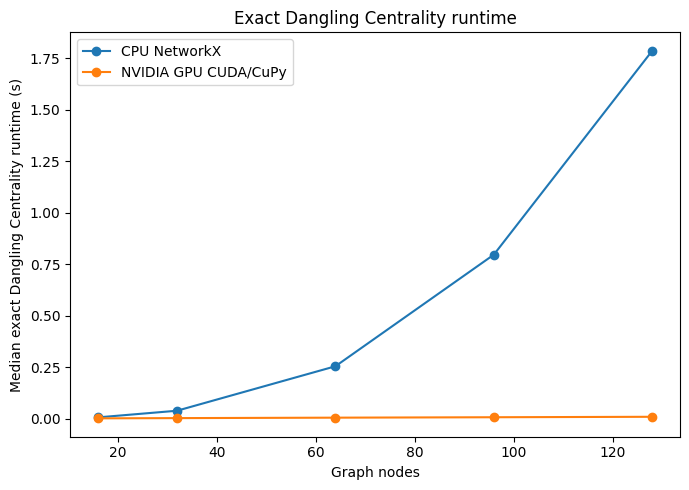

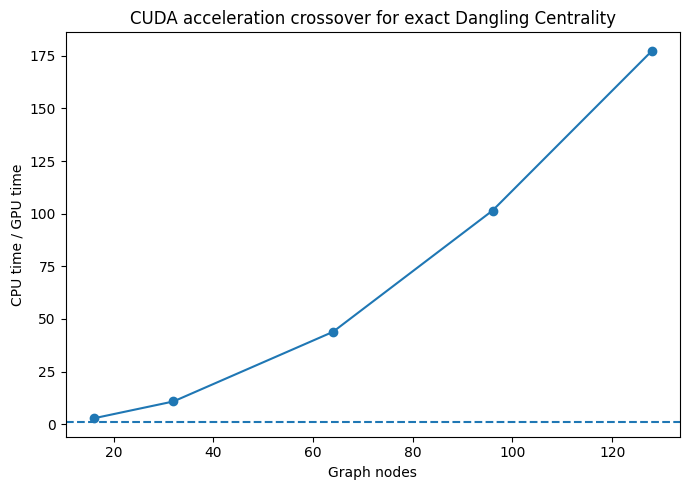

Saved: /content/gtc_2027_gpu_attention_benchmark/dc_runtime_cpu_vs_gpu.png
Saved: /content/gtc_2027_gpu_attention_benchmark/dc_speedup_by_graph_size.png


In [30]:
GTC_OUTPUT_DIR = Path("/content/gtc_2027_gpu_attention_benchmark")
GTC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not gtc_scale_benchmark_df.empty:
    plt.figure(figsize=(7, 5))
    plt.plot(
        gtc_scale_benchmark_df["n_nodes"],
        gtc_scale_benchmark_df["cpu_dc_seconds"],
        marker="o",
        label="CPU NetworkX"
    )
    plt.plot(
        gtc_scale_benchmark_df["n_nodes"],
        gtc_scale_benchmark_df["gpu_dc_seconds"],
        marker="o",
        label="NVIDIA GPU CUDA/CuPy"
    )
    plt.xlabel("Graph nodes")
    plt.ylabel("Median exact Dangling Centrality runtime (s)")
    plt.title("Exact Dangling Centrality runtime")
    plt.legend()
    plt.tight_layout()
    runtime_fig = GTC_OUTPUT_DIR / "dc_runtime_cpu_vs_gpu.png"
    plt.savefig(runtime_fig, dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(
        gtc_scale_benchmark_df["n_nodes"],
        gtc_scale_benchmark_df["dc_speedup_cpu_over_gpu"],
        marker="o"
    )
    plt.axhline(1.0, linestyle="--")
    plt.xlabel("Graph nodes")
    plt.ylabel("CPU time / GPU time")
    plt.title("CUDA acceleration crossover for exact Dangling Centrality")
    plt.tight_layout()
    speedup_fig = GTC_OUTPUT_DIR / "dc_speedup_by_graph_size.png"
    plt.savefig(speedup_fig, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", runtime_fig)
    print("Saved:", speedup_fig)


## GTC-H. Optional NVIDIA RAPIDS `nx-cugraph` check

Dangling Centrality is custom, so the main benchmark above uses CUDA/CuPy. This optional test verifies that the environment can also dispatch a standard NetworkX algorithm through NVIDIA RAPIDS.


In [31]:
try:
    import nx_cugraph as nxcg

    rapids_graph = make_topk_like_graph(2000, top_k=5, seed=SEED)
    rapids_gpu_graph = nxcg.from_networkx(rapids_graph)

    pr_cpu_seconds = median_runtime_seconds(
        lambda: nx.pagerank(rapids_graph),
        repeats=3,
        gpu=False
    )

    pr_gpu_seconds = median_runtime_seconds(
        lambda: nx.pagerank(rapids_gpu_graph),
        repeats=3,
        gpu=True
    )

    print("RAPIDS nx-cugraph available:", True)
    print("PageRank CPU seconds:", pr_cpu_seconds)
    print("PageRank GPU seconds:", pr_gpu_seconds)
    print("PageRank speedup:", pr_cpu_seconds / pr_gpu_seconds)

except Exception as exc:
    print("Optional nx-cugraph test skipped.")
    print("Reason:", repr(exc))


RAPIDS nx-cugraph available: True
PageRank CPU seconds: 0.010004567000123643
PageRank GPU seconds: 0.0032895480001116084
PageRank speedup: 3.041319658440675


## GTC-I. Save benchmark evidence and environment metadata


In [32]:
gtc_metadata = {
    "model": MODEL_NAME,
    "dataset": DATASET_NAME,
    "dataset_split": DATASET_SPLIT,
    "max_length": MAX_LENGTH,
    "top_k_edges_per_node": TOP_K_EDGES_PER_NODE,
    "seed": SEED,
    "python": platform.python_version(),
    "pytorch": torch.__version__,
    "networkx": nx.__version__,
    "cupy": cp.__version__,
    "cuda_runtime": torch.version.cuda,
    "gpu_name": torch.cuda.get_device_name(0),
    "gpu_memory_gb": round(
        torch.cuda.get_device_properties(0).total_memory / 1e9, 3
    ),
}

with open(GTC_OUTPUT_DIR / "environment_metadata.json", "w") as f:
    json.dump(gtc_metadata, f, indent=2)

if not gtc_real_benchmark_df.empty:
    gtc_real_benchmark_df.to_csv(
        GTC_OUTPUT_DIR / "real_medmcqa_cpu_gpu_benchmark.csv",
        index=False
    )

if not gtc_real_failures_df.empty:
    gtc_real_failures_df.to_csv(
        GTC_OUTPUT_DIR / "real_medmcqa_failures.csv",
        index=False
    )

if "gtc_real_summary" in globals():
    gtc_real_summary.to_csv(
        GTC_OUTPUT_DIR / "real_medmcqa_summary.csv",
        index=False
    )

gtc_scale_benchmark_df.to_csv(
    GTC_OUTPUT_DIR / "scale_cpu_gpu_benchmark.csv",
    index=False
)

print("Saved files:")
for path in sorted(GTC_OUTPUT_DIR.iterdir()):
    print(" -", path.name)


Saved files:
 - dc_runtime_cpu_vs_gpu.png
 - dc_speedup_by_graph_size.png
 - environment_metadata.json
 - real_medmcqa_cpu_gpu_benchmark.csv
 - real_medmcqa_summary.csv
 - scale_cpu_gpu_benchmark.csv


## GTC-J. Decision gate

After running the notebook:

- If **real MedMCQA graphs** show meaningful GPU speedup, proceed to 200–1,000 questions and report end-to-end throughput.
- If real graphs are CPU-faster, do not force the claim. Increase workload scale, batch graphs by token count, and benchmark the complete CUDA BioGPT + graph-auditing pipeline.
- Keep the intervention/faithfulness results from the main notebook as the **scientific validation** layer.
- Keep synthetic scale tests explicitly labelled as **compute-scaling evidence**, not biomedical evidence.

The next milestone is therefore evidence, not poster design: obtain a correct CPU/GPU agreement table and the first measured runtime table.


## GTC-K. 200-question real-graph benchmark — scale and statistical robustness

The 10-question pilot established numerical agreement and a preliminary median GPU speedup. This section scales the benchmark to **200 real MedMCQA/BioGPT attention graphs** and pre-specifies the statistics used for the NVIDIA GTC evidence.

**Primary performance endpoint**

\[
S_i = \frac{T_{CPU,i}}{T_{GPU,i}}
\]

where each runtime is the median of repeated measurements on the same graph. The principal summary is the **median real-graph speedup**, accompanied by a nonparametric bootstrap 95% confidence interval. We also report the geometric mean speedup, IQR, paired Wilcoxon test, graph-size/speedup Spearman association, throughput, and numerical agreement.

The first 200 validation questions are used deterministically to match the existing notebook's 200-question experimental scale. Synthetic graphs remain separate from this biomedical benchmark.


In [33]:
from scipy.stats import spearmanr, wilcoxon

GTC_ROBUST_N = min(200, len(dataset))
GTC_ROBUST_REPEATS = 3
GTC_BOOTSTRAP_DRAWS = 10000
GTC_CHECKPOINT_EVERY = 10

GTC_ROBUST_OUTPUT_DIR = GTC_OUTPUT_DIR / "real_200_robust"
GTC_ROBUST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GTC_ROBUST_CHECKPOINT = GTC_ROBUST_OUTPUT_DIR / "real_medmcqa_200_checkpoint.csv"
GTC_ROBUST_FAILURES = GTC_ROBUST_OUTPUT_DIR / "real_medmcqa_200_failures.csv"

GTC_ROBUST_INDICES = list(range(GTC_ROBUST_N))

print("Robust benchmark questions:", GTC_ROBUST_N)
print("Timing repeats per CPU/GPU implementation:", GTC_ROBUST_REPEATS)
print("Bootstrap draws:", GTC_BOOTSTRAP_DRAWS)
print("Checkpoint:", GTC_ROBUST_CHECKPOINT)


Robust benchmark questions: 200
Timing repeats per CPU/GPU implementation: 3
Bootstrap draws: 10000
Checkpoint: /content/gtc_2027_gpu_attention_benchmark/real_200_robust/real_medmcqa_200_checkpoint.csv


### GTC-K1. Run / resume the 200-question benchmark

This cell is checkpointed. If Colab stops after some questions, rerun the notebook setup and then this cell; already completed question indices are skipped.


In [34]:
# Resume safely from a previous checkpoint if present.
if GTC_ROBUST_CHECKPOINT.exists():
    robust_existing_df = pd.read_csv(GTC_ROBUST_CHECKPOINT)
    robust_rows = robust_existing_df.to_dict("records")
    completed_indices = set(robust_existing_df["question_index"].astype(int).tolist())
    print(f"Resuming from {len(completed_indices)} completed questions.")
else:
    robust_rows = []
    completed_indices = set()

if GTC_ROBUST_FAILURES.exists():
    robust_failure_df_existing = pd.read_csv(GTC_ROBUST_FAILURES)
    robust_failure_rows = robust_failure_df_existing.to_dict("records")
    failed_indices = set(robust_failure_df_existing["question_index"].astype(int).tolist())
else:
    robust_failure_rows = []
    failed_indices = set()

run_start = time.time()
new_since_checkpoint = 0

for position, question_index in enumerate(GTC_ROBUST_INDICES, start=1):
    if question_index in completed_indices:
        continue

    try:
        item = gtc_attention_graph_for_question(question_index)
        graph = item["graph"]

        bench = benchmark_dc_pair(
            graph,
            repeats=GTC_ROBUST_REPEATS
        )

        row = {
            "question_index": int(question_index),
            "biogpt_cuda_inference_seconds": float(item["inference_seconds"]),
            "graph_build_seconds": float(item["graph_build_seconds"]),
            **bench,
        }
        robust_rows.append(row)
        completed_indices.add(question_index)
        new_since_checkpoint += 1

        print(
            f"{len(completed_indices):3d}/{GTC_ROBUST_N} | "
            f"q={question_index:3d} | "
            f"nodes={graph.number_of_nodes():3d} | "
            f"edges={graph.number_of_edges():4d} | "
            f"speedup={bench['dc_speedup_cpu_over_gpu']:8.3f}x | "
            f"agreement={bench['agreement_passed']}"
        )

    except Exception as exc:
        # Keep a record; do not silently replace failed cases.
        robust_failure_rows.append({
            "question_index": int(question_index),
            "error": repr(exc),
        })
        failed_indices.add(question_index)
        print("FAILED", question_index, repr(exc))

    if new_since_checkpoint >= GTC_CHECKPOINT_EVERY:
        pd.DataFrame(robust_rows).sort_values("question_index").to_csv(
            GTC_ROBUST_CHECKPOINT,
            index=False
        )
        pd.DataFrame(robust_failure_rows).to_csv(
            GTC_ROBUST_FAILURES,
            index=False
        )
        new_since_checkpoint = 0
        elapsed_min = (time.time() - run_start) / 60
        print(
            f"Checkpoint saved | completed={len(completed_indices)} "
            f"| failures={len(robust_failure_rows)} | elapsed={elapsed_min:.1f} min"
        )

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    cp.get_default_memory_pool().free_all_blocks()

# Final save.
gtc_robust_df = (
    pd.DataFrame(robust_rows)
    .drop_duplicates(subset=["question_index"], keep="last")
    .sort_values("question_index")
    .reset_index(drop=True)
)

gtc_robust_failures_df = pd.DataFrame(robust_failure_rows)

gtc_robust_df.to_csv(GTC_ROBUST_CHECKPOINT, index=False)
gtc_robust_failures_df.to_csv(GTC_ROBUST_FAILURES, index=False)

print("\nCompleted benchmark rows:", len(gtc_robust_df))
print("Failure records:", len(gtc_robust_failures_df))
display(gtc_robust_df.head())
display(gtc_robust_failures_df.head())

if not gtc_robust_df.empty:
    assert gtc_robust_df["agreement_passed"].all(), (
        "At least one CPU/GPU Dangling Centrality comparison failed numerical agreement."
    )


  1/200 | q=  0 | nodes= 58 | edges= 275 | speedup=  35.036x | agreement=True
  2/200 | q=  1 | nodes= 77 | edges= 370 | speedup=  62.580x | agreement=True
  3/200 | q=  2 | nodes=105 | edges= 510 | speedup= 117.675x | agreement=True
  4/200 | q=  3 | nodes= 18 | edges=  75 | speedup=   3.492x | agreement=True
  5/200 | q=  4 | nodes= 27 | edges= 120 | speedup=   7.756x | agreement=True
  6/200 | q=  5 | nodes= 16 | edges=  65 | speedup=   2.730x | agreement=True
  7/200 | q=  6 | nodes= 63 | edges= 300 | speedup=  41.232x | agreement=True
  8/200 | q=  7 | nodes= 39 | edges= 180 | speedup=  15.857x | agreement=True
  9/200 | q=  8 | nodes= 23 | edges= 100 | speedup=   5.511x | agreement=True
 10/200 | q=  9 | nodes= 44 | edges= 205 | speedup=  20.778x | agreement=True
Checkpoint saved | completed=10 | failures=0 | elapsed=0.2 min
 11/200 | q= 10 | nodes= 30 | edges= 135 | speedup=   9.539x | agreement=True
 12/200 | q= 11 | nodes= 82 | edges= 395 | speedup=  72.536x | agreement=True
 

,question_index,biogpt_cuda_inference_seconds,graph_build_seconds,n_nodes,n_edges,cpu_dc_seconds,gpu_dc_seconds,dc_speedup_cpu_over_gpu,max_abs_error,agreement_passed
0,0,0.078201,0.004914,58,275,0.189442,0.005407,35.036107,1.354433e-07,True
1,1,0.111554,0.008383,77,370,0.415525,0.006640,62.580441,2.145289e-07,True
2,2,0.186407,0.015531,105,510,0.998890,0.008489,117.675040,1.194702e-07,True
3,3,0.026283,0.000654,18,75,0.009228,0.002643,3.491552,4.723116e-08,True
4,4,0.034384,0.001237,27,120,0.025499,0.003288,7.755646,7.517753e-08,True


""


### GTC-K2. Statistical robustness and confidence intervals

The speedup distribution can be highly right-skewed because larger attention graphs give much greater GPU advantage. Therefore the **median** is the primary performance summary; the **geometric mean** is included as a secondary multiplicative summary rather than relying on the arithmetic mean alone.


In [35]:
def bootstrap_ci(values, statistic, draws=10000, seed=42, confidence=0.95):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return (np.nan, np.nan)

    rng = np.random.default_rng(seed)
    n = len(values)
    stats = np.empty(draws, dtype=float)

    for b in range(draws):
        sample = values[rng.integers(0, n, size=n)]
        stats[b] = statistic(sample)

    alpha = (1.0 - confidence) / 2.0
    return (
        float(np.quantile(stats, alpha)),
        float(np.quantile(stats, 1.0 - alpha)),
    )


def geometric_mean_positive(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0)]
    return float(np.exp(np.mean(np.log(values)))) if len(values) else np.nan


analysis_df = gtc_robust_df.copy()
analysis_df = analysis_df[
    analysis_df["agreement_passed"].astype(bool)
    & np.isfinite(analysis_df["cpu_dc_seconds"])
    & np.isfinite(analysis_df["gpu_dc_seconds"])
    & (analysis_df["cpu_dc_seconds"] > 0)
    & (analysis_df["gpu_dc_seconds"] > 0)
].copy()

analysis_df["dc_speedup_cpu_over_gpu"] = (
    analysis_df["cpu_dc_seconds"] / analysis_df["gpu_dc_seconds"]
)
analysis_df["log_speedup"] = np.log(analysis_df["dc_speedup_cpu_over_gpu"])

speedups = analysis_df["dc_speedup_cpu_over_gpu"].to_numpy(float)

median_speedup = float(np.median(speedups))
mean_speedup = float(np.mean(speedups))
geom_speedup = geometric_mean_positive(speedups)
q1_speedup = float(np.quantile(speedups, 0.25))
q3_speedup = float(np.quantile(speedups, 0.75))

median_ci = bootstrap_ci(
    speedups,
    np.median,
    draws=GTC_BOOTSTRAP_DRAWS,
    seed=SEED
)
mean_ci = bootstrap_ci(
    speedups,
    np.mean,
    draws=GTC_BOOTSTRAP_DRAWS,
    seed=SEED + 1
)
geom_ci = bootstrap_ci(
    speedups,
    geometric_mean_positive,
    draws=GTC_BOOTSTRAP_DRAWS,
    seed=SEED + 2
)

# Paired test of whether CPU exact-DC runtime is greater than GPU exact-DC runtime.
wilcox = wilcoxon(
    analysis_df["cpu_dc_seconds"].to_numpy(float),
    analysis_df["gpu_dc_seconds"].to_numpy(float),
    alternative="greater",
    zero_method="wilcox"
)

rho_nodes, p_nodes = spearmanr(
    analysis_df["n_nodes"],
    analysis_df["dc_speedup_cpu_over_gpu"]
)
rho_edges, p_edges = spearmanr(
    analysis_df["n_edges"],
    analysis_df["dc_speedup_cpu_over_gpu"]
)

n_valid = len(analysis_df)
percent_gpu_faster = 100.0 * float((speedups > 1.0).mean())
percent_over_2x = 100.0 * float((speedups >= 2.0).mean())
percent_over_10x = 100.0 * float((speedups >= 10.0).mean())

max_error = float(analysis_df["max_abs_error"].max())

# DC-only throughput. These totals sum the independently benchmarked median runtimes.
total_cpu_dc = float(analysis_df["cpu_dc_seconds"].sum())
total_gpu_dc = float(analysis_df["gpu_dc_seconds"].sum())
cpu_dc_throughput = n_valid / total_cpu_dc if total_cpu_dc > 0 else np.nan
gpu_dc_throughput = n_valid / total_gpu_dc if total_gpu_dc > 0 else np.nan

# Practical pipeline comparison while holding BioGPT inference constant on the NVIDIA GPU.
# Graph construction is identical/common; only the exact DC backend changes.
analysis_df["pipeline_cpu_graph_seconds"] = (
    analysis_df["biogpt_cuda_inference_seconds"]
    + analysis_df["graph_build_seconds"]
    + analysis_df["cpu_dc_seconds"]
)
analysis_df["pipeline_gpu_graph_seconds"] = (
    analysis_df["biogpt_cuda_inference_seconds"]
    + analysis_df["graph_build_seconds"]
    + analysis_df["gpu_dc_seconds"]
)

total_pipeline_cpu_graph = float(analysis_df["pipeline_cpu_graph_seconds"].sum())
total_pipeline_gpu_graph = float(analysis_df["pipeline_gpu_graph_seconds"].sum())
end_to_end_speedup = (
    total_pipeline_cpu_graph / total_pipeline_gpu_graph
    if total_pipeline_gpu_graph > 0 else np.nan
)
end_to_end_time_reduction_pct = (
    100.0 * (1.0 - total_pipeline_gpu_graph / total_pipeline_cpu_graph)
    if total_pipeline_cpu_graph > 0 else np.nan
)
end_to_end_cpu_graph_qps = (
    n_valid / total_pipeline_cpu_graph if total_pipeline_cpu_graph > 0 else np.nan
)
end_to_end_gpu_graph_qps = (
    n_valid / total_pipeline_gpu_graph if total_pipeline_gpu_graph > 0 else np.nan
)

gtc_robust_summary = pd.DataFrame([{
    "n_requested": GTC_ROBUST_N,
    "n_valid": n_valid,
    "n_failures": len(gtc_robust_failures_df),
    "median_nodes": float(analysis_df["n_nodes"].median()),
    "median_edges": float(analysis_df["n_edges"].median()),
    "median_speedup": median_speedup,
    "median_speedup_ci95_low": median_ci[0],
    "median_speedup_ci95_high": median_ci[1],
    "geometric_mean_speedup": geom_speedup,
    "geometric_mean_ci95_low": geom_ci[0],
    "geometric_mean_ci95_high": geom_ci[1],
    "arithmetic_mean_speedup": mean_speedup,
    "mean_speedup_ci95_low": mean_ci[0],
    "mean_speedup_ci95_high": mean_ci[1],
    "speedup_q1": q1_speedup,
    "speedup_q3": q3_speedup,
    "percent_gpu_faster": percent_gpu_faster,
    "percent_at_least_2x": percent_over_2x,
    "percent_at_least_10x": percent_over_10x,
    "wilcoxon_statistic_cpu_gt_gpu": float(wilcox.statistic),
    "wilcoxon_p_one_sided": float(wilcox.pvalue),
    "spearman_nodes_vs_speedup_rho": float(rho_nodes),
    "spearman_nodes_vs_speedup_p": float(p_nodes),
    "spearman_edges_vs_speedup_rho": float(rho_edges),
    "spearman_edges_vs_speedup_p": float(p_edges),
    "cpu_dc_total_seconds": total_cpu_dc,
    "gpu_dc_total_seconds": total_gpu_dc,
    "cpu_dc_graphs_per_second": cpu_dc_throughput,
    "gpu_dc_graphs_per_second": gpu_dc_throughput,
    "fixed_gpu_inference_pipeline_cpu_graph_seconds": total_pipeline_cpu_graph,
    "fixed_gpu_inference_pipeline_gpu_graph_seconds": total_pipeline_gpu_graph,
    "fixed_gpu_inference_pipeline_speedup": end_to_end_speedup,
    "fixed_gpu_inference_pipeline_time_reduction_pct": end_to_end_time_reduction_pct,
    "fixed_gpu_inference_pipeline_cpu_graph_qps": end_to_end_cpu_graph_qps,
    "fixed_gpu_inference_pipeline_gpu_graph_qps": end_to_end_gpu_graph_qps,
    "max_cpu_gpu_dc_abs_error": max_error,
}])

display(gtc_robust_summary.T.rename(columns={0: "value"}))

print(
    f"Primary result: median exact-DC speedup = {median_speedup:.2f}x "
    f"(bootstrap 95% CI {median_ci[0]:.2f}–{median_ci[1]:.2f}x)"
)
print(
    f"Geometric mean speedup = {geom_speedup:.2f}x "
    f"(bootstrap 95% CI {geom_ci[0]:.2f}–{geom_ci[1]:.2f}x)"
)
print(
    f"GPU faster on {percent_gpu_faster:.1f}% of valid real graphs; "
    f">=10x on {percent_over_10x:.1f}%."
)
print(
    f"Paired Wilcoxon CPU > GPU: statistic={wilcox.statistic:.3f}, "
    f"p={wilcox.pvalue:.3e}"
)
print(
    f"Spearman nodes vs speedup: rho={rho_nodes:.3f}, p={p_nodes:.3e}"
)
print(
    f"Fixed-GPU-inference end-to-end pipeline speedup from GPU graph auditing: "
    f"{end_to_end_speedup:.2f}x; time reduction={end_to_end_time_reduction_pct:.1f}%"
)


,value
n_requested,2.000000e+02
n_valid,2.000000e+02
n_failures,0.000000e+00
median_nodes,3.000000e+01
median_edges,1.350000e+02
median_speedup,9.198119e+00
median_speedup_ci95_low,8.283606e+00
median_speedup_ci95_high,1.061499e+01
geometric_mean_speedup,1.068736e+01
geometric_mean_ci95_low,9.740643e+00


Primary result: median exact-DC speedup = 9.20x (bootstrap 95% CI 8.28–10.61x)
Geometric mean speedup = 10.69x (bootstrap 95% CI 9.74–11.75x)
GPU faster on 100.0% of valid real graphs; >=10x on 44.5%.
Paired Wilcoxon CPU > GPU: statistic=20100.000, p=7.181e-35
Spearman nodes vs speedup: rho=0.998, p=1.039e-242
Fixed-GPU-inference end-to-end pipeline speedup from GPU graph auditing: 2.20x; time reduction=54.5%


### GTC-K3. Real-graph size strata

This table checks whether acceleration is confined to only the largest questions. Quartiles are defined from the **observed real BioGPT graph sizes**, not synthetic graphs.


In [36]:
strata_df = analysis_df.copy()
strata_df["node_size_quartile"] = pd.qcut(
    strata_df["n_nodes"],
    q=4,
    duplicates="drop"
)

gtc_size_strata_summary = (
    strata_df
    .groupby("node_size_quartile", observed=True)
    .agg(
        n_graphs=("question_index", "count"),
        median_nodes=("n_nodes", "median"),
        median_edges=("n_edges", "median"),
        median_cpu_dc_s=("cpu_dc_seconds", "median"),
        median_gpu_dc_s=("gpu_dc_seconds", "median"),
        median_speedup=("dc_speedup_cpu_over_gpu", "median"),
        q1_speedup=("dc_speedup_cpu_over_gpu", lambda x: x.quantile(0.25)),
        q3_speedup=("dc_speedup_cpu_over_gpu", lambda x: x.quantile(0.75)),
    )
    .reset_index()
)

gtc_size_strata_summary["node_size_quartile"] = (
    gtc_size_strata_summary["node_size_quartile"].astype(str)
)

display(gtc_size_strata_summary)


,node_size_quartile,n_graphs,median_nodes,median_edges,median_cpu_dc_s,median_gpu_dc_s,median_speedup,q1_speedup,q3_speedup
0,"(15.999, 24.75]",50,22.0,95.0,0.015248,0.002924,5.280869,4.665674,5.704925
1,"(24.75, 30.0]",60,27.5,122.5,0.026639,0.003374,7.754340,7.085537,8.815413
2,"(30.0, 40.0]",41,35.0,160.0,0.049822,0.003852,12.944772,11.329138,15.337781
3,"(40.0, 105.0]",49,48.0,225.0,0.115139,0.004767,23.656934,21.433432,34.807131


### GTC-K4. Poster-quality figures from 200 real biomedical graphs

These figures use only real MedMCQA/BioGPT attention graphs. Synthetic scaling figures from GTC-F should remain labelled separately.


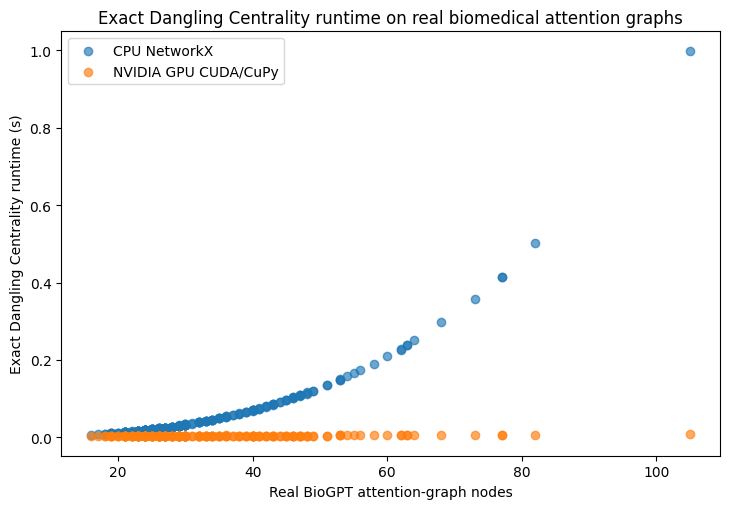

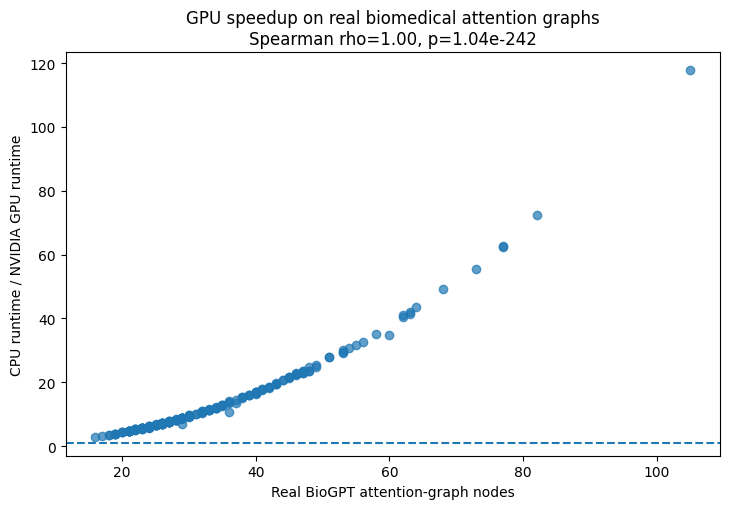

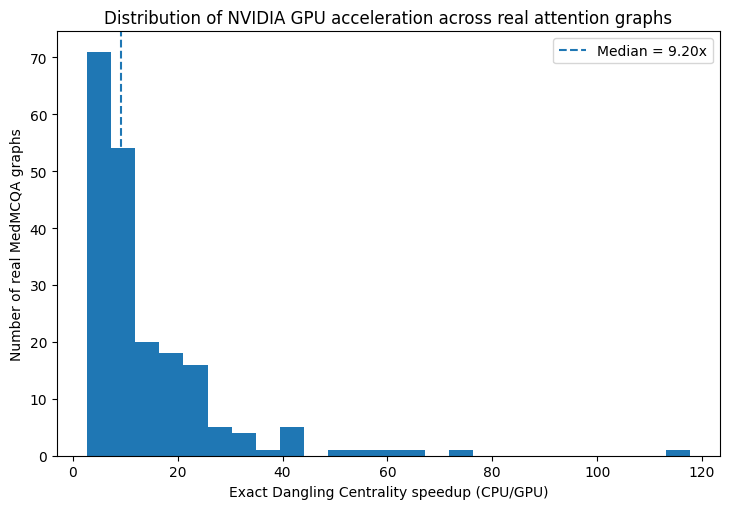

Saved poster-quality figures:
 - /content/gtc_2027_gpu_attention_benchmark/real_200_robust/real200_runtime_vs_nodes.png
 - /content/gtc_2027_gpu_attention_benchmark/real_200_robust/real200_speedup_vs_nodes.png
 - /content/gtc_2027_gpu_attention_benchmark/real_200_robust/real200_speedup_distribution.png


In [37]:
# Figure 1: CPU and GPU exact-DC runtime against real graph size.
plt.figure(figsize=(7.4, 5.2))
plt.scatter(
    analysis_df["n_nodes"],
    analysis_df["cpu_dc_seconds"],
    alpha=0.65,
    label="CPU NetworkX"
)
plt.scatter(
    analysis_df["n_nodes"],
    analysis_df["gpu_dc_seconds"],
    alpha=0.65,
    label="NVIDIA GPU CUDA/CuPy"
)
plt.xlabel("Real BioGPT attention-graph nodes")
plt.ylabel("Exact Dangling Centrality runtime (s)")
plt.title("Exact Dangling Centrality runtime on real biomedical attention graphs")
plt.legend()
plt.tight_layout()
fig1 = GTC_ROBUST_OUTPUT_DIR / "real200_runtime_vs_nodes.png"
plt.savefig(fig1, dpi=300, bbox_inches="tight")
plt.show()

# Figure 2: speedup as graph size grows.
plt.figure(figsize=(7.4, 5.2))
plt.scatter(
    analysis_df["n_nodes"],
    analysis_df["dc_speedup_cpu_over_gpu"],
    alpha=0.70
)
plt.axhline(1.0, linestyle="--")
plt.xlabel("Real BioGPT attention-graph nodes")
plt.ylabel("CPU runtime / NVIDIA GPU runtime")
plt.title(
    "GPU speedup on real biomedical attention graphs\n"
    f"Spearman rho={rho_nodes:.2f}, p={p_nodes:.2e}"
)
plt.tight_layout()
fig2 = GTC_ROBUST_OUTPUT_DIR / "real200_speedup_vs_nodes.png"
plt.savefig(fig2, dpi=300, bbox_inches="tight")
plt.show()

# Figure 3: real-graph speedup distribution.
plt.figure(figsize=(7.4, 5.2))
plt.hist(
    analysis_df["dc_speedup_cpu_over_gpu"],
    bins=25
)
plt.axvline(median_speedup, linestyle="--", label=f"Median = {median_speedup:.2f}x")
plt.xlabel("Exact Dangling Centrality speedup (CPU/GPU)")
plt.ylabel("Number of real MedMCQA graphs")
plt.title("Distribution of NVIDIA GPU acceleration across real attention graphs")
plt.legend()
plt.tight_layout()
fig3 = GTC_ROBUST_OUTPUT_DIR / "real200_speedup_distribution.png"
plt.savefig(fig3, dpi=300, bbox_inches="tight")
plt.show()

print("Saved poster-quality figures:")
print(" -", fig1)
print(" -", fig2)
print(" -", fig3)


### GTC-K5. Save statistical evidence, reproducibility metadata, and a ZIP bundle

The ZIP bundle contains the raw 200-question benchmark, failures, robust summary, size-stratified results, environment metadata, and 300-dpi figures. Keep these raw files with the poster submission record so every headline number remains auditable.


In [38]:
# Save the per-question table with derived pipeline times.
analysis_df.to_csv(
    GTC_ROBUST_OUTPUT_DIR / "real_medmcqa_200_valid_benchmark.csv",
    index=False
)

gtc_robust_summary.to_csv(
    GTC_ROBUST_OUTPUT_DIR / "real_medmcqa_200_statistical_summary.csv",
    index=False
)

gtc_size_strata_summary.to_csv(
    GTC_ROBUST_OUTPUT_DIR / "real_medmcqa_200_size_strata.csv",
    index=False
)

robust_metadata = dict(gtc_metadata)
robust_metadata.update({
    "robust_n_requested": int(GTC_ROBUST_N),
    "robust_n_valid": int(len(analysis_df)),
    "robust_benchmark_repeats": int(GTC_ROBUST_REPEATS),
    "bootstrap_draws": int(GTC_BOOTSTRAP_DRAWS),
    "real_question_selection": "deterministic first N validation questions",
    "primary_endpoint": "median per-graph exact Dangling Centrality speedup CPU/GPU",
    "confidence_interval": "nonparametric percentile bootstrap 95% CI",
    "paired_test": "one-sided Wilcoxon signed-rank test, CPU runtime > GPU runtime",
})

with open(GTC_ROBUST_OUTPUT_DIR / "robust_environment_metadata.json", "w") as f:
    json.dump(robust_metadata, f, indent=2)

# Human-readable one-page text summary for poster drafting.
summary_txt = GTC_ROBUST_OUTPUT_DIR / "GTC_200Q_RESULT_SUMMARY.txt"
with open(summary_txt, "w") as f:
    f.write("NVIDIA GTC 2027 — 200-question real BioGPT attention-graph benchmark\n")
    f.write("=" * 74 + "\n")
    f.write(f"Valid real graphs: {n_valid}/{GTC_ROBUST_N}\n")
    f.write(
        f"Primary median speedup: {median_speedup:.3f}x "
        f"(bootstrap 95% CI {median_ci[0]:.3f}–{median_ci[1]:.3f}x)\n"
    )
    f.write(
        f"Geometric mean speedup: {geom_speedup:.3f}x "
        f"(bootstrap 95% CI {geom_ci[0]:.3f}–{geom_ci[1]:.3f}x)\n"
    )
    f.write(f"IQR of speedup: {q1_speedup:.3f}–{q3_speedup:.3f}x\n")
    f.write(f"GPU faster on: {percent_gpu_faster:.2f}% of valid graphs\n")
    f.write(f"At least 10x faster on: {percent_over_10x:.2f}% of valid graphs\n")
    f.write(
        f"Wilcoxon CPU > GPU: statistic={wilcox.statistic:.4f}, "
        f"p={wilcox.pvalue:.6e}\n"
    )
    f.write(
        f"Nodes vs speedup Spearman: rho={rho_nodes:.4f}, p={p_nodes:.6e}\n"
    )
    f.write(f"DC-only CPU throughput: {cpu_dc_throughput:.3f} graphs/s\n")
    f.write(f"DC-only GPU throughput: {gpu_dc_throughput:.3f} graphs/s\n")
    f.write(
        f"Fixed-GPU-inference full pipeline speedup from GPU graph auditing: "
        f"{end_to_end_speedup:.3f}x\n"
    )
    f.write(
        f"Fixed-GPU-inference pipeline time reduction: "
        f"{end_to_end_time_reduction_pct:.2f}%\n"
    )
    f.write(f"Maximum CPU/GPU DC absolute error: {max_error:.6e}\n")

zip_base = Path("/content/NVIDIA_GTC_2027_200Q_Robust_Benchmark")
zip_path = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=str(GTC_ROBUST_OUTPUT_DIR)
)

print("\nSaved robust evidence bundle:", zip_path)
print("\nFiles in robust output directory:")
for path in sorted(GTC_ROBUST_OUTPUT_DIR.iterdir()):
    print(" -", path.name)



Saved robust evidence bundle: /content/NVIDIA_GTC_2027_200Q_Robust_Benchmark.zip

Files in robust output directory:
 - GTC_200Q_RESULT_SUMMARY.txt
 - real200_runtime_vs_nodes.png
 - real200_speedup_distribution.png
 - real200_speedup_vs_nodes.png
 - real_medmcqa_200_checkpoint.csv
 - real_medmcqa_200_failures.csv
 - real_medmcqa_200_size_strata.csv
 - real_medmcqa_200_statistical_summary.csv
 - real_medmcqa_200_valid_benchmark.csv
 - robust_environment_metadata.json


## GTC-L. Claim gate for the poster

Use the following hierarchy when writing the NVIDIA GTC poster:

1. **Primary biomedical claim:** report the 200-real-graph median speedup and its bootstrap 95% CI.
2. **Correctness claim:** report the maximum CPU/GPU numerical discrepancy and state that all valid graphs passed the pre-specified agreement threshold.
3. **Scalability claim:** report the real-graph Spearman relationship between graph size and speedup; keep the synthetic 16–128 node experiment as separate compute-scaling evidence.
4. **Practical-pipeline claim:** report the end-to-end speedup obtained when BioGPT inference remains on the same NVIDIA GPU and only the graph-auditing backend changes from CPU to CUDA/CuPy.
5. Do **not** headline the single maximum speedup. The median + 95% CI is more defensible.
6. If the 200-question median CI is still clearly above 1× and numerical agreement remains intact, the acceleration result is statistically robust enough to carry into the poster. If not, report the mixed result rather than forcing an acceleration claim.
